# IMDb TV Series Participations Analysis
## Q16: Collaborative Relationships per Genre

This analysis explores which pairs of participants have the strongest collaborative relationships, appearing together in the most titles, broken down by genre.

**Research Question:** Which pairs of participants have the strongest collaborative relationships appearing together in the most titles per genre?

In [41]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# Set visualization defaults
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

# Define paths - gold notebook is in gold/ so we go up one level to the project root
project_root = Path.cwd().parent
silver_path = project_root / "data/silver"
gold_path = project_root / "data/gold"

print("✓ Libraries imported successfully")
print(f"  Project root: {project_root}")
print(f"  Silver path: {silver_path}")
print(f"  Gold path: {gold_path}")

✓ Libraries imported successfully
  Project root: c:\Users\davib\Desktop\MSc_DataScience\DataWarehouse\lab_assignment\imbd
  Silver path: c:\Users\davib\Desktop\MSc_DataScience\DataWarehouse\lab_assignment\imbd\data\silver
  Gold path: c:\Users\davib\Desktop\MSc_DataScience\DataWarehouse\lab_assignment\imbd\data\gold


In [2]:
# Load fact_participations, dim_genres, and bridge_genres
print("Loading data from silver layer...")

fact_participations = pd.read_parquet(silver_path / 'participations_pers.parquet')
dim_genres = pd.read_parquet(silver_path / 'dim_genres.parquet')
bridge_genres = pd.read_parquet(silver_path / 'bridge_genres.parquet')

print(f"✓ fact_participations shape: {fact_participations.shape}")
print(f"✓ dim_genres shape: {dim_genres.shape}")
print(f"✓ bridge_genres shape: {bridge_genres.shape}")
print(f"\nfact_participations columns: {fact_participations.columns.tolist()}")
print(f"\nSample fact_participations:\n{fact_participations.head()}")

Loading data from silver layer...
✓ fact_participations shape: (906524, 14)
✓ dim_genres shape: (27, 2)
✓ bridge_genres shape: (162249, 4)

fact_participations columns: ['sk_person', 'primaryName', 'sk_title', 'titleType', 'primaryTitle', 'runtimeMinutes', 'sk_genre_group', 'sk_role', 'category', 'job', 'characters', 'sk_profession_group', 'sk_kwn_title_group', 'participation_count']

Sample fact_participations:
   sk_person           primaryName   sk_title titleType        primaryTitle  \
0  nm1014554  Shelley Calene-Black  tt0111056  tvSeries  Gensomaden Saiyuki   
1  nm1365013           Braden Hunt  tt0111056  tvSeries  Gensomaden Saiyuki   
2  nm0410907          Akira Ishida  tt0111056  tvSeries  Gensomaden Saiyuki   
3  nm1408401             John Area  tt0111056  tvSeries  Gensomaden Saiyuki   
4  nm1020018    Christine M. Auten  tt0111056  tvSeries  Gensomaden Saiyuki   

   runtimeMinutes sk_genre_group                   sk_role category   job  \
0            23.0        g_grp_1

In [3]:
# Enrich participations with genre information
print("Enriching participations with genre information...")

# Join fact_participations with bridge_genres to add genre details
participations_with_genres = fact_participations.merge(
    bridge_genres[['sk_title', 'sk_genre']],
    on='sk_title',
    how='left'
).merge(
    dim_genres[['sk_genre', 'genre_nm']],
    on='sk_genre',
    how='left'
)

print(f"✓ Participations enriched shape: {participations_with_genres.shape}")
print(f"\nSample enriched data:\n{participations_with_genres[['sk_person', 'primaryName', 'sk_title', 'primaryTitle', 'genre_nm']].head(10)}")

Enriching participations with genre information...
✓ Participations enriched shape: (1332900, 16)

Sample enriched data:
   sk_person           primaryName   sk_title        primaryTitle   genre_nm
0  nm1014554  Shelley Calene-Black  tt0111056  Gensomaden Saiyuki     Action
1  nm1014554  Shelley Calene-Black  tt0111056  Gensomaden Saiyuki  Adventure
2  nm1014554  Shelley Calene-Black  tt0111056  Gensomaden Saiyuki  Animation
3  nm1365013           Braden Hunt  tt0111056  Gensomaden Saiyuki     Action
4  nm1365013           Braden Hunt  tt0111056  Gensomaden Saiyuki  Adventure
5  nm1365013           Braden Hunt  tt0111056  Gensomaden Saiyuki  Animation
6  nm0410907          Akira Ishida  tt0111056  Gensomaden Saiyuki     Action
7  nm0410907          Akira Ishida  tt0111056  Gensomaden Saiyuki  Adventure
8  nm0410907          Akira Ishida  tt0111056  Gensomaden Saiyuki  Animation
9  nm1408401             John Area  tt0111056  Gensomaden Saiyuki     Action


In [ ]:
# Compute collaborative pairs per genre (Vectorized Matrix Approach)
print("Computing collaborative relationships per genre using vectorized operations...")

# Enrich participations with genres
participations_enriched = fact_participations[['sk_person', 'primaryName', 'sk_title']].copy()
participations_enriched = participations_enriched.merge(
    bridge_genres[['sk_title', 'sk_genre']],
    on='sk_title',
    how='left'
).merge(
    dim_genres[['sk_genre', 'genre_nm']],
    on='sk_genre',
    how='left'
)

# Keep only records with genre information
participations_enriched = participations_enriched[participations_enriched['genre_nm'].notna()].drop_duplicates()

print(f"  Enriched data: {len(participations_enriched)} records")

# Build collaboration pairs using vectorized operations
collabs_list = []

# For each genre, create a co-occurrence matrix
for genre in participations_enriched['genre_nm'].unique():
    genre_data = participations_enriched[participations_enriched['genre_nm'] == genre]
    
    # Get unique persons per title in this genre
    title_to_persons = genre_data.groupby('sk_title')['sk_person'].apply(list).reset_index()
    
    # Vectorized pair generation using cross products
    for _, row in title_to_persons.iterrows():
        persons = row['sk_person']
        if len(persons) >= 2:
            # Use vectorized approach: create all pairs
            persons_array = np.array(persons)
            # Generate pairs more efficiently
            for i in range(len(persons_array)):
                for j in range(i + 1, len(persons_array)):
                    p1, p2 = persons_array[i], persons_array[j]
                    # Ensure consistent ordering
                    if p1 > p2:
                        p1, p2 = p2, p1
                    collabs_list.append([genre, p1, p2, row['sk_title']])

print(f"  Collaboration instances found: {len(collabs_list)}")

# Convert to DataFrame and aggregate
collabs_df = pd.DataFrame(collabs_list, columns=['genre', 'person1_id', 'person2_id', 'title_id'])

# Vectorized aggregation
collabs_agg = collabs_df.groupby(['genre', 'person1_id', 'person2_id']).size().reset_index(name='shared_titles_count')

# Map person names
person_name_map = fact_participations[['sk_person', 'primaryName']].drop_duplicates().set_index('sk_person')['primaryName'].to_dict()
collabs_agg['person1_name'] = collabs_agg['person1_id'].map(person_name_map)
collabs_agg['person2_name'] = collabs_agg['person2_id'].map(person_name_map)

# Sort by shared titles
collabs_agg = collabs_agg.sort_values('shared_titles_count', ascending=False)

print(f"\n✓ Unique collaborations computed: {len(collabs_agg)}")
print(f"✓ Genres covered: {collabs_agg['genre'].nunique()}")
print(f"\nTop 15 collaborations across all genres:")
print(collabs_agg.head(505)[['genre', 'person1_name', 'person2_name', 'shared_titles_count']])

Computing collaborative relationships per genre using vectorized operations...
  Enriched data: 1119654 records
  Collaboration instances found: 4354554

✓ Unique collaborations computed: 4228728
✓ Genres covered: 27

Top 15 collaborations across all genres:
             genre    person1_name    person2_name  shared_titles_count
4152618  Talk-Show   Eric Whiteley   Aaron Elliott                   62
3977871  Talk-Show    Calvin Grubb   Eric Whiteley                   51
3977873  Talk-Show    Calvin Grubb   Aaron Elliott                   49
4152617  Talk-Show   Eric Whiteley    Shane Farley                   46
4152619  Talk-Show    Shane Farley   Aaron Elliott                   43
3977872  Talk-Show    Calvin Grubb    Shane Farley                   43
3977889  Talk-Show  Richard Martin   Eric Whiteley                   37
3003139      Music     Neil Turbin       Jimmy Kay                   37
3977855  Talk-Show    Calvin Grubb  Richard Martin                   36
3977891  Talk-Show  R

In [42]:
top_10_collabs_by_genre = (
    collabs_agg
    .sort_values(['genre', 'shared_titles_count'], ascending=[True, False])
    .groupby('genre')
    .head(5)
    .reset_index(drop=True)
)

top_10_collabs_by_genre.head(100)

,genre,person1_id,person2_id,shared_titles_count,person1_name,person2_name
0,Action,nm0160049,nm0722676,11,Luci Christian,Monica Rial
1,Action,nm0160049,nm0666547,11,Luci Christian,Chris Patton
2,Action,nm0160049,nm0351758,10,Luci Christian,Hilary Haag
3,Action,nm0160049,nm1364905,10,Luci Christian,Greg Ayres
4,Action,nm0056532,nm0238546,9,Kathleen Barr,Brian Drummond
...,...,...,...,...,...,...
95,Romance,nm10884168,nm11404451,8,Kenzie Mackenzie Espoir Paterson,Genevieve Begbie
96,Romance,nm10884168,nm11399036,8,Kenzie Mackenzie Espoir Paterson,Kass Kassidy Campbell
97,Romance,nm11399036,nm11404451,7,Kass Kassidy Campbell,Genevieve Begbie
98,Romance,nm11399036,nm11399037,7,Kass Kassidy Campbell,Trevor Wells


In [44]:
top_10_collabs_by_genre.to_parquet(gold_path / 'top_collaborations_by_genre.parquet', index=False)

In [13]:
# Top collaborations per genre
print("\n" + "="*80)
print("TOP COLLABORATIONS BY GENRE")
print("="*80)

genres_sorted = collabs_agg['genre'].value_counts().index

for genre in genres_sorted[:10]:  # Top 10 genres with collaborations
    genre_collabs = collabs_agg[collabs_agg['genre'] == genre].nlargest(5, 'shared_titles_count')
    
    print(f"\n📺 {genre.upper()}")
    print("-" * 80)
    if len(genre_collabs) > 0:
        for idx, row in genre_collabs.iterrows():
            print(f"  {row['person1_name']} ❤️  {row['person2_name']}")
            print(f"    └─ Shared {row['shared_titles_count']} titles")
    else:
        print("  No collaborations found")


TOP COLLABORATIONS BY GENRE

📺 COMEDY
--------------------------------------------------------------------------------
  Rafi Fine ❤️  Benny Fine
    └─ Shared 28 titles
  Lewis Brindley ❤️  Duncan Jones
    └─ Shared 27 titles
  Lewis Brindley ❤️  Simon Lane
    └─ Shared 27 titles
  Paul Sykes ❤️  Duncan Jones
    └─ Shared 22 titles
  Simon Lane ❤️  Duncan Jones
    └─ Shared 22 titles

📺 DRAMA
--------------------------------------------------------------------------------
  Kenzie Mackenzie Espoir Paterson ❤️  Kevin Wilcox
    └─ Shared 12 titles
  Huifang Hong ❤️  Hou Ren Choo
    └─ Shared 11 titles
  David Dalton ❤️  Chad Schnackel
    └─ Shared 11 titles
  Shucheng Chen ❤️  Hou Ren Choo
    └─ Shared 11 titles
  Cynthia Koh ❤️  Yinji Jin
    └─ Shared 10 titles

📺 REALITY-TV
--------------------------------------------------------------------------------
  Cris Abrego ❤️  Mark Cronin
    └─ Shared 19 titles
  Drew Scott ❤️  Jonathan Silver Scott
    └─ Shared 14 titles
  Casp

In [15]:
# Statistical Summary
print("\n" + "="*80)
print("COLLABORATION STATISTICS BY GENRE")
print("="*80)

genre_stats = collabs_agg.groupby('genre').agg({
    'shared_titles_count': ['count', 'mean', 'median', 'max']
}).round(2)

genre_stats.columns = ['Pairs Count', 'Avg Shared Titles', 'Median Shared Titles', 'Max Shared Titles']
genre_stats = genre_stats.sort_values('Max Shared Titles', ascending=False)

print(genre_stats.head(15))


COLLABORATION STATISTICS BY GENRE
             Pairs Count  Avg Shared Titles  Median Shared Titles  \
genre                                                               
Talk-Show         271111               1.02                   1.0   
Music             100290               1.02                   1.0   
Animation         160218               1.14                   1.0   
Comedy            962642               1.04                   1.0   
Reality-TV        271352               1.03                   1.0   
Adventure         120104               1.04                   1.0   
Fantasy            82297               1.02                   1.0   
News               78022               1.03                   1.0   
Drama             708957               1.03                   1.0   
Action            159851               1.04                   1.0   
Sport              71220               1.05                   1.0   
Documentary       225658               1.01                   1.0   

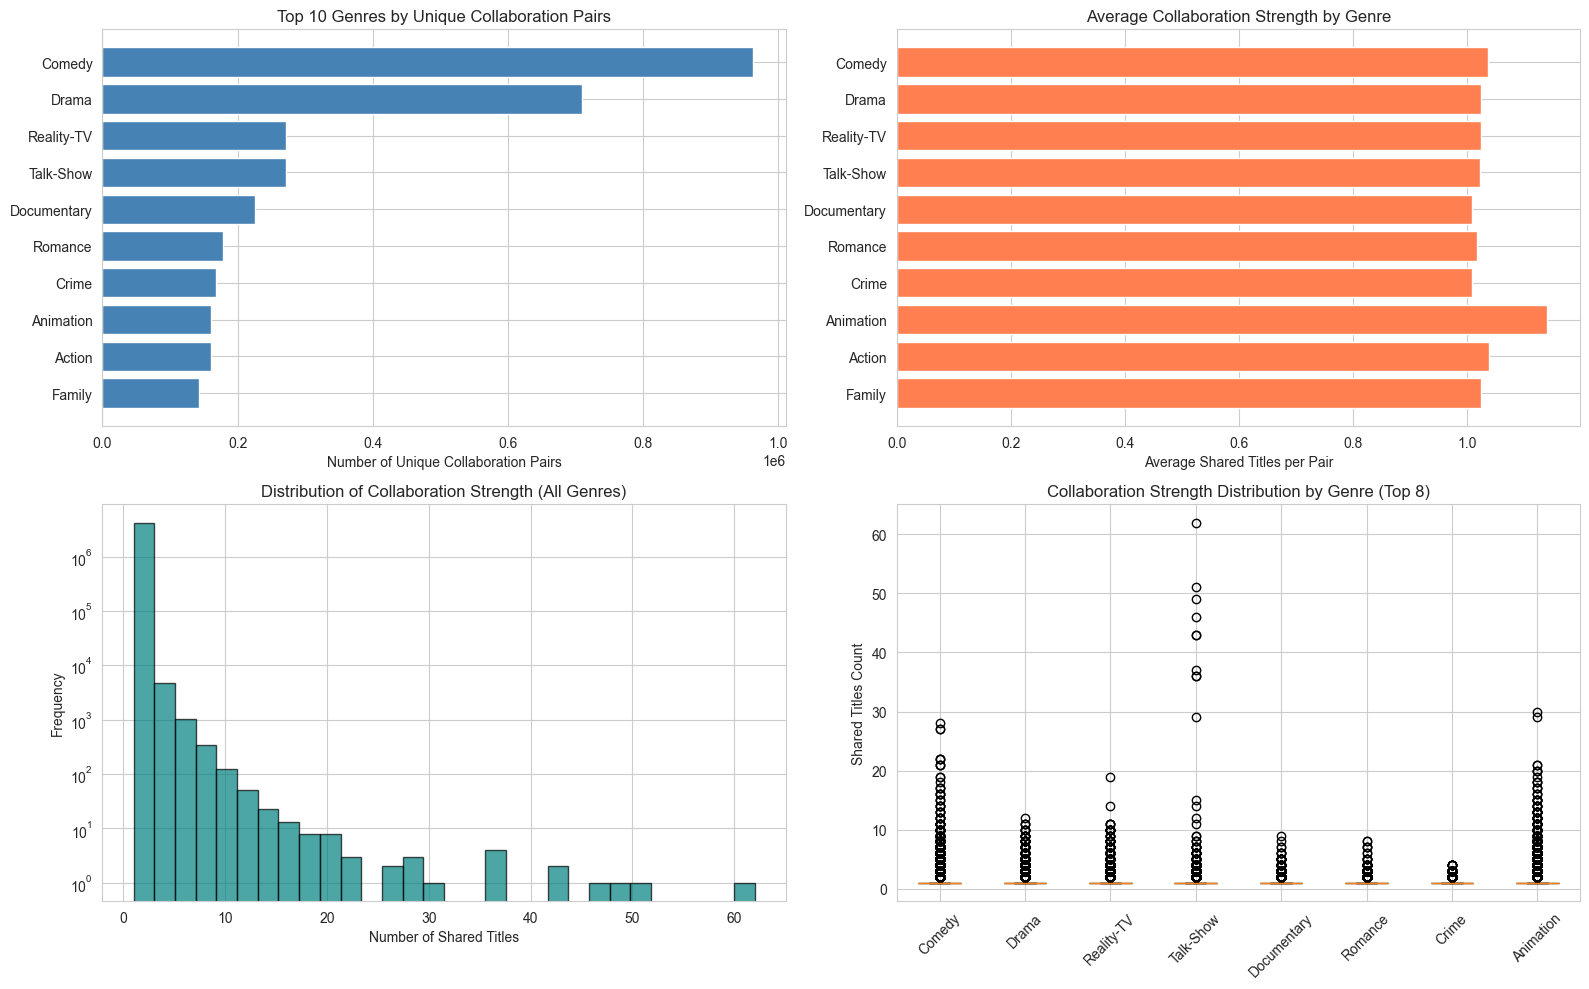

✓ Visualization saved as 'collaborations_overview.png'


In [16]:
# Visualization 1: Distribution of collaboration strength by genre
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Top 10 genres by number of unique pairs
top_genres_by_pairs = collabs_agg['genre'].value_counts().head(10)
axes[0, 0].barh(range(len(top_genres_by_pairs)), top_genres_by_pairs.values, color='steelblue')
axes[0, 0].set_yticks(range(len(top_genres_by_pairs)))
axes[0, 0].set_yticklabels(top_genres_by_pairs.index)
axes[0, 0].set_xlabel('Number of Unique Collaboration Pairs')
axes[0, 0].set_title('Top 10 Genres by Unique Collaboration Pairs')
axes[0, 0].invert_yaxis()

# Plot 2: Average collaboration strength by genre
top_genres = collabs_agg['genre'].value_counts().head(10).index
avg_collabs = [collabs_agg[collabs_agg['genre'] == g]['shared_titles_count'].mean() for g in top_genres]
axes[0, 1].barh(range(len(avg_collabs)), avg_collabs, color='coral')
axes[0, 1].set_yticks(range(len(avg_collabs)))
axes[0, 1].set_yticklabels(top_genres)
axes[0, 1].set_xlabel('Average Shared Titles per Pair')
axes[0, 1].set_title('Average Collaboration Strength by Genre')
axes[0, 1].invert_yaxis()

# Plot 3: Distribution of shared titles
axes[1, 0].hist(collabs_agg['shared_titles_count'], bins=30, color='teal', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Number of Shared Titles')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Collaboration Strength (All Genres)')
axes[1, 0].set_yscale('log')

# Plot 4: Box plot of shared titles by top 8 genres
top_8_genres = collabs_agg['genre'].value_counts().head(8).index
data_for_box = [collabs_agg[collabs_agg['genre'] == g]['shared_titles_count'].values for g in top_8_genres]
bp = axes[1, 1].boxplot(data_for_box, labels=top_8_genres, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
axes[1, 1].set_ylabel('Shared Titles Count')
axes[1, 1].set_title('Collaboration Strength Distribution by Genre (Top 8)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
# plt.savefig(project_root / 'collaborations_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization saved as 'collaborations_overview.png'")

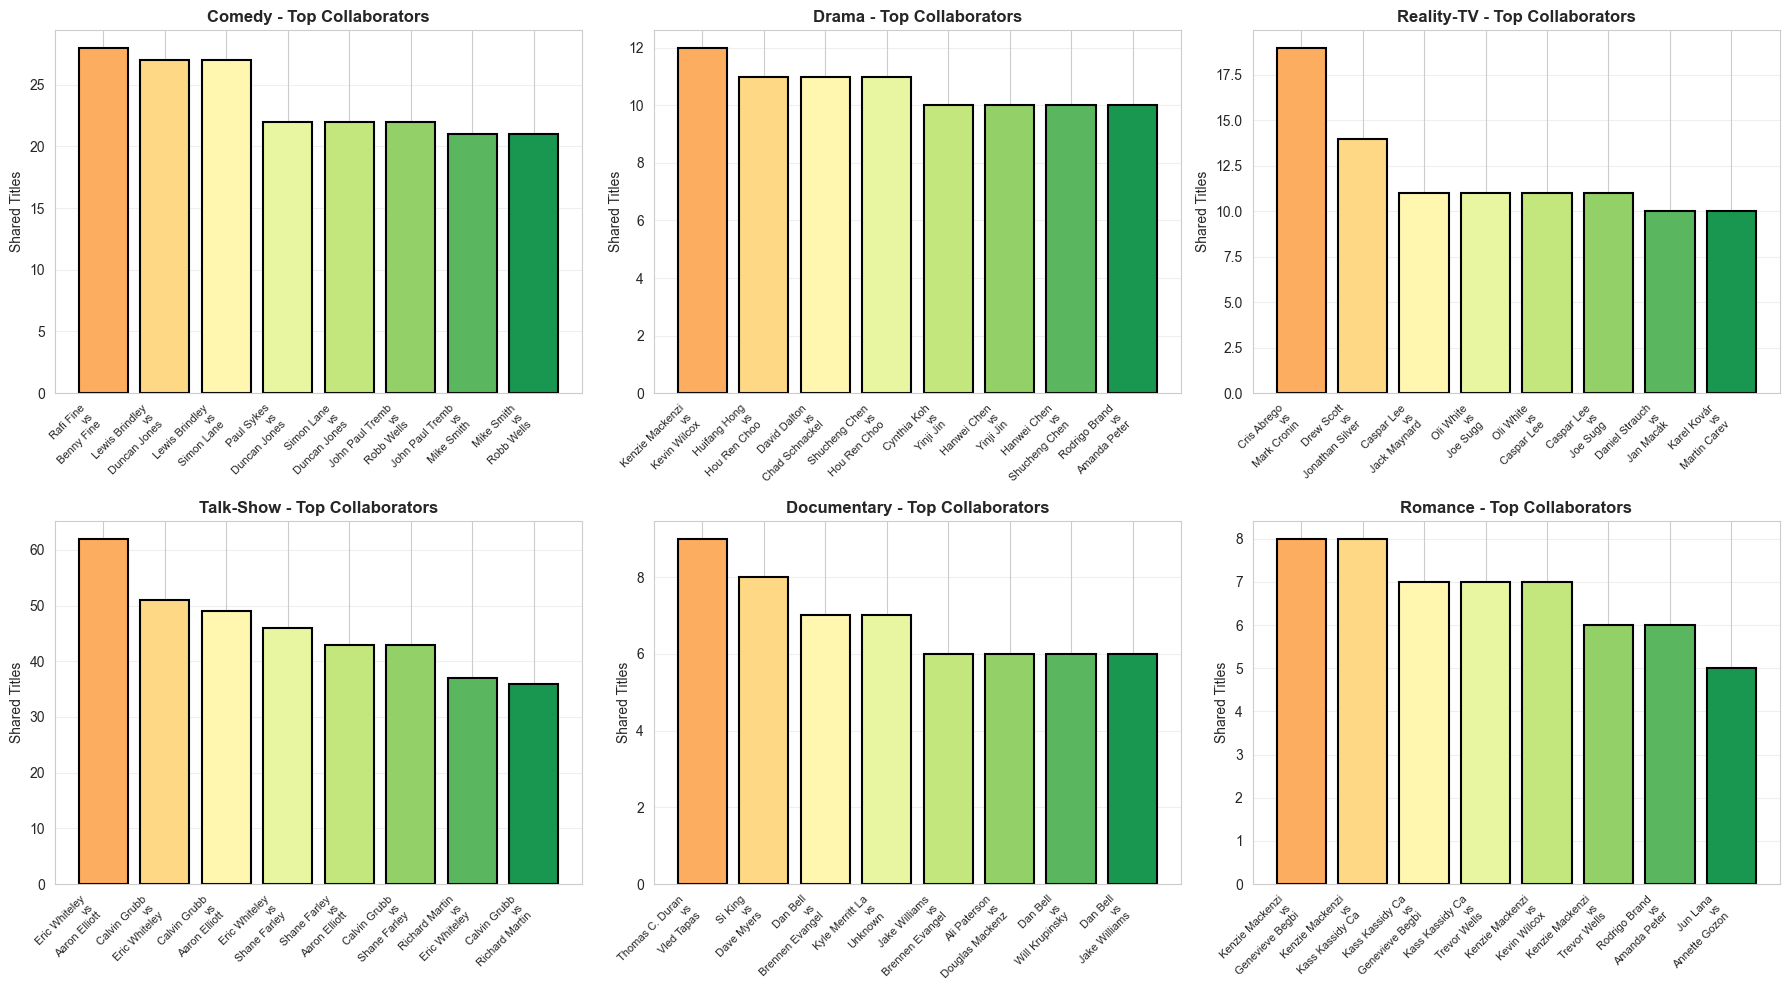

✓ Top collaborators visualization complete


In [18]:
# Visualization 2: Top collaborators per selected genres
top_genres_detailed = collabs_agg['genre'].value_counts().head(6).index

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, genre in enumerate(top_genres_detailed):
    genre_data = collabs_agg[collabs_agg['genre'] == genre].nlargest(8, 'shared_titles_count')
    
    if len(genre_data) > 0:
        # Handle None values in names
        pair_labels = []
        for _, row in genre_data.iterrows():
            p1_name = str(row['person1_name'])[:15] if row['person1_name'] else 'Unknown'
            p2_name = str(row['person2_name'])[:15] if row['person2_name'] else 'Unknown'
            pair_labels.append(f"{p1_name}\nvs\n{p2_name}")
        
        values = genre_data['shared_titles_count'].values
        
        colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(values)))
        axes[idx].bar(range(len(values)), values, color=colors, edgecolor='black', linewidth=1.5)
        axes[idx].set_xticks(range(len(values)))
        axes[idx].set_xticklabels(pair_labels, fontsize=8, rotation=45, ha='right')
        axes[idx].set_ylabel('Shared Titles')
        axes[idx].set_title(f'{genre} - Top Collaborators', fontweight='bold')
        axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Top collaborators visualization complete")

In [10]:
# Most Prolific Collaborators Analysis
print("\n" + "="*80)
print("MOST PROLIFIC COLLABORATORS")
print("="*80)

# Find people who collaborate most frequently
person1_collabs = collabs_agg.groupby('person1_id').agg({
    'person1_name': 'first',
    'shared_titles_count': 'sum',
    'genre': 'count'
}).rename(columns={'shared_titles_count': 'total_collab_strength', 'genre': 'num_unique_pairs'})

person2_collabs = collabs_agg.groupby('person2_id').agg({
    'person2_name': 'first',
    'shared_titles_count': 'sum',
    'genre': 'count'
}).rename(columns={'shared_titles_count': 'total_collab_strength', 'genre': 'num_unique_pairs'})

# Combine both directions
all_person_collabs = pd.concat([
    person1_collabs.rename(index=lambda x: x, columns={'person1_name': 'person_name'}),
    person2_collabs.rename(index=lambda x: x, columns={'person2_name': 'person_name'})
], axis=0)

# Aggregate by person
person_collab_summary = all_person_collabs.groupby(all_person_collabs.index).agg({
    'person_name': 'first',
    'total_collab_strength': 'sum',
    'num_unique_pairs': 'sum'
}).sort_values('total_collab_strength', ascending=False)

print("\nTop 15 Most Active Collaborators (by total shared titles across all pairs):")
print(person_collab_summary.head(15)[['person_name', 'total_collab_strength', 'num_unique_pairs']])

# Show cross-genre collaboration
print("\n" + "="*80)
print("CROSS-GENRE COLLABORATION PATTERNS")
print("="*80)

# Find pairs that collaborate in multiple genres
pair_genre_count = collabs_agg.groupby(['person1_id', 'person2_id'])['genre'].agg(['count', 'nunique']).reset_index()
pair_genre_count.columns = ['person1_id', 'person2_id', 'total_collabs', 'num_genres']

# Add names using person_name_map
pair_genre_count['person1_name'] = pair_genre_count['person1_id'].map(person_name_map)
pair_genre_count['person2_name'] = pair_genre_count['person2_id'].map(person_name_map)

multi_genre_pairs = pair_genre_count[pair_genre_count['num_genres'] > 1].sort_values('num_genres', ascending=False)

print(f"\n{len(multi_genre_pairs)} pairs collaborate across multiple genres\n")
print("Top 10 pairs working across multiple genres:")
print(multi_genre_pairs.head(10)[['person1_name', 'person2_name', 'total_collabs', 'num_genres']])


MOST PROLIFIC COLLABORATORS

Top 15 Most Active Collaborators (by total shared titles across all pairs):
                        person_name  total_collab_strength  num_unique_pairs
nm0722676               Monica Rial                   3093              1762
nm0160049            Luci Christian                   3059              1789
nm1931870        Brittney Karbowski                   2175              1282
nm0217221              Grey Griffin                   2100              1390
nm0444786                 Tom Kenny                   1856              1363
nm1364905                Greg Ayres                   1836              1197
nm2573928             Kana Hanazawa                   1831              1310
nm1920556            Todd Haberkorn                   1773              1249
nm1489841              Jamie Marchi                   1722              1130
nm0048389         Dee Bradley Baker                   1699              1252
nm1101677              Jun Fukuyama            

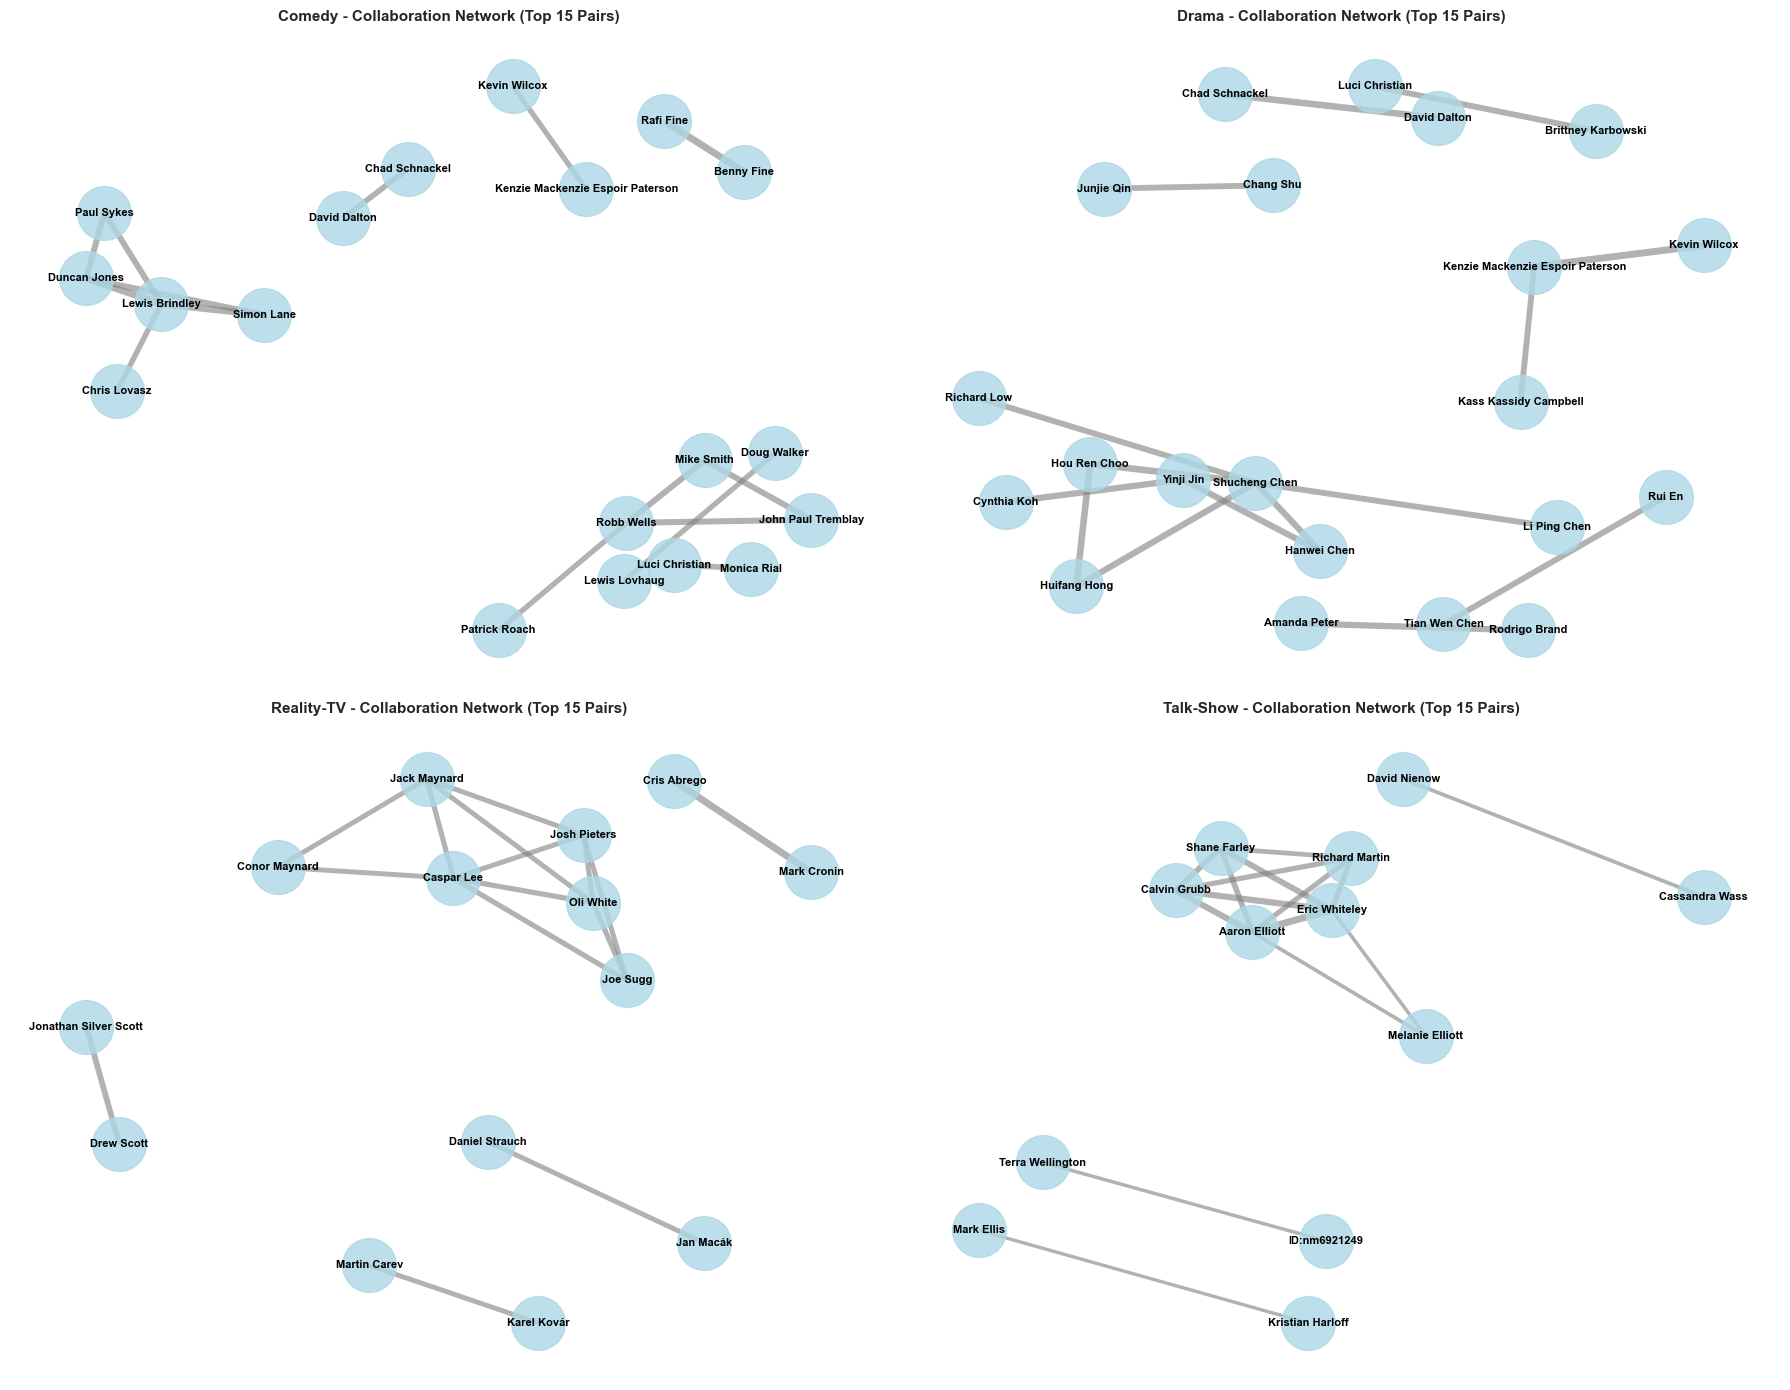

✓ Network visualization saved as 'collaboration_networks.png'


In [12]:
# Visualization 3: Genre-specific collaboration networks
import networkx as nx

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

# Top 4 genres for network visualization
top_4_genres = collabs_agg['genre'].value_counts().head(4).index

for idx, genre in enumerate(top_4_genres):
    genre_collabs = collabs_agg[collabs_agg['genre'] == genre]
    
    # Filter to top collaborations for clarity
    top_collabs = genre_collabs.nlargest(15, 'shared_titles_count')
    
    # Create network graph
    G = nx.Graph()
    
    for _, row in top_collabs.iterrows():
        # Handle None values
        p1_name = str(row['person1_name']) if row['person1_name'] else f"ID:{row['person1_id']}"
        p2_name = str(row['person2_name']) if row['person2_name'] else f"ID:{row['person2_id']}"
        
        G.add_edge(p1_name, p2_name, weight=row['shared_titles_count'])
    
    if len(G.nodes()) > 0:
        # Layout
        pos = nx.spring_layout(G, k=2, iterations=50, seed=42)
        
        # Draw
        ax = axes[idx]
        nx.draw_networkx_nodes(G, pos, node_color='lightblue', 
                              node_size=1500, ax=ax, alpha=0.8)
        
        # Draw edges with varying widths
        edges = G.edges()
        weights = [G[u][v]['weight'] for u, v in edges]
        max_weight = max(weights) if weights else 1
        
        nx.draw_networkx_edges(G, pos, width=[2 + 3*(w/max_weight) for w in weights],
                              alpha=0.6, ax=ax, edge_color='gray')
        
        nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=ax)
        
        ax.set_title(f'{genre} - Collaboration Network (Top 15 Pairs)', fontweight='bold', fontsize=11)
        ax.axis('off')

plt.tight_layout()
plt.savefig(project_root / 'collaboration_networks.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Network visualization saved as 'collaboration_networks.png'")

In [17]:
# Export results to CSV files
print("\n" + "="*80)
print("EXPORTING ANALYSIS RESULTS")
print("="*80)

# Export 1: Overall collaborations with genre
collabs_export = collabs_agg[[
    'genre', 'person1_name', 'person2_name', 'shared_titles_count'
]].copy()
collabs_export = collabs_export.sort_values(['genre', 'shared_titles_count'], ascending=[True, False])
collabs_export.to_csv(project_root / 'collaborations_by_genre.csv', index=False)
print("✓ Exported 'collaborations_by_genre.csv'")

# Export 2: Genre-level statistics
genre_stats = collabs_agg.groupby('genre').agg({
    'shared_titles_count': ['count', 'mean', 'median', 'max']
}).round(2)
genre_stats.columns = ['Pairs Count', 'Avg Shared Titles', 'Median Shared Titles', 'Max Shared Titles']
genre_stats = genre_stats.sort_values('Max Shared Titles', ascending=False)
genre_stats.to_csv(project_root / 'genre_collaboration_stats.csv')
print("✓ Exported 'genre_collaboration_stats.csv'")

# Export 3: Person-level collaboration summary
person_export = person_collab_summary.reset_index().rename(columns={'index': 'person_id'})
person_export = person_export.sort_values('total_collab_strength', ascending=False)
person_export.to_csv(project_root / 'person_collaboration_summary.csv', index=False)
print("✓ Exported 'person_collaboration_summary.csv'")

# Export 4: Top pairs
top_pairs_export = pair_genre_count.sort_values('total_collabs', ascending=False)
top_pairs_export.to_csv(project_root / 'top_collaboration_pairs.csv', index=False)
print("✓ Exported 'top_collaboration_pairs.csv'")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print(f"\n✓ Generated {len(collabs_agg)} unique collaborations across {collabs_agg['genre'].nunique()} genres")
print(f"✓ Involved {len(person_name_map)} unique participants")
print(f"✓ Spanning {len(collabs_df)} total collaboration instances")
print(f"\n📁 All results saved to: {project_root}")


EXPORTING ANALYSIS RESULTS
✓ Exported 'collaborations_by_genre.csv'
✓ Exported 'genre_collaboration_stats.csv'
✓ Exported 'person_collaboration_summary.csv'
✓ Exported 'top_collaboration_pairs.csv'

ANALYSIS COMPLETE

✓ Generated 4228728 unique collaborations across 27 genres
✓ Involved 444549 unique participants
✓ Spanning 4354554 total collaboration instances

📁 All results saved to: c:\Users\davib\Desktop\MSc_DataScience\DataWarehouse\lab_assignment\imbd


# Analysis Ideas: Participant Patterns & Specialization

## Idea 1: Genre Specialization Score
**Question:** Which participants are genre specialists vs. generalists? How does specialization correlate with participation count?

**Approach:** Calculate Herfindahl index for each participant to measure genre concentration. Higher index = more specialized (focused on few genres), lower = generalist.


In [51]:
# ANALYSIS 1: Genre Specialization Score (Fast Vectorized)
print("\n" + "="*80)
print("ANALYSIS 1: GENRE SPECIALIZATION SCORE")
print("="*80)
print("Question: Which participants are genre specialists vs. generalists?")
print()

# Vectorized: count unique genres per person
genre_count = (
    participations_enriched[['sk_person', 'genre_nm']]
    .drop_duplicates()
    .groupby('sk_person')
    .size()
)

# Participation count
participant_count = participations_enriched['sk_person'].value_counts()

# Combine
specialization = pd.DataFrame({
    'num_genres': genre_count,
    'participation_count': participant_count
})

# Add person names
specialization['person_name'] = specialization.index.map(person_name_map)

# Specialization ratio: titles per genre
specialization['intensity'] = specialization['participation_count'] / specialization['num_genres']
specialization = specialization.sort_values('num_genres')

print("SPECIALISTS (work in only 1-2 genres):")
specialists = specialization[specialization['num_genres'] <= 2].nlargest(10, 'participation_count')
print(specialists[['person_name', 'num_genres', 'participation_count', 'intensity']])

print("\n\nGENERALISTS (work in many genres):")
generalists = specialization[specialization['num_genres'] > 10].nlargest(10, 'participation_count')
print(generalists[['person_name', 'num_genres', 'participation_count', 'intensity']])

print(f"\n\nAverage: {specialization['num_genres'].mean():.2f} genres per participant")


ANALYSIS 1: GENRE SPECIALIZATION SCORE
Question: Which participants are genre specialists vs. generalists?

SPECIALISTS (work in only 1-2 genres):
               person_name  num_genres  participation_count  intensity
sk_person                                                             
nm8966144     David Nienow           2                   48       24.0
nm10244808       Jimmy Kay           2                   43       21.5
nm10101975     Neil Turbin           2                   40       20.0
nm1458998        Yinji Jin           2                   35       17.5
nm2798578   Liverpool F.C.           2                   28       14.0
nm9993327      Gilad James           1                   23       23.0
nm1053118    Raul A. Reyes           2                   23       11.5
nm2296553     Sue Galloway           2                   23       11.5
nm5298876             None           2                   22       11.0
nm6072896     Broden Kelly           2                   22       11.0


In [52]:
specialization = pd.concat([specialists, generalists])

In [53]:
specialization

,num_genres,participation_count,person_name,intensity
sk_person,,,,
nm8966144,2,48,David Nienow,24.000000
nm10244808,2,43,Jimmy Kay,21.500000
nm10101975,2,40,Neil Turbin,20.000000
nm1458998,2,35,Yinji Jin,17.500000
nm2798578,2,28,Liverpool F.C.,14.000000
nm9993327,1,23,Gilad James,23.000000
nm1053118,2,23,Raul A. Reyes,11.500000
nm2296553,2,23,Sue Galloway,11.500000
nm5298876,2,22,None,11.000000


In [54]:
specialization.to_parquet(gold_path / 'genre_specialization.parquet', index=True)

## Idea 2: Role Category Distribution
**Question:** What are the most common roles (actor, director, writer, etc.) and which genres attract specific roles?

**Approach:** Group fact_participations by category (role type) and genre, count occurrences, identify patterns using vectorized groupby operations.


In [34]:
# ANALYSIS 2: Role Category Distribution
print("\n" + "="*80)
print("ANALYSIS 2: ROLE CATEGORY DISTRIBUTION BY GENRE")
print("="*80)
print("Question: What roles are most common? Which genres prefer which roles?")
print()

par_enriched_gen = fact_participations.merge(
    bridge_genres[['sk_title', 'sk_genre']],
    on='sk_title',
    how='left'
).merge(
    dim_genres[['sk_genre', 'genre_nm']],
    on='sk_genre',
    how='left'
)
# Vectorized role analysis
role_genre_dist = (
    par_enriched_gen
    .dropna(subset=['category', 'genre_nm'])
    [['category', 'genre_nm']]
    .groupby(['category', 'genre_nm'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

# Overall role distribution
role_totals = fact_participations['category'].value_counts().head(10)
print("\nTop 10 Most Common Roles (Overall):")
print(role_totals)

# Genre-role preference: which genres have unusual role compositions
print("\n\nRole Specialization by Genre (most common role % of total):")
role_genre_pcts = (
    par_enriched_gen
    .dropna(subset=['category', 'genre_nm'])
    .groupby('genre_nm')
    .apply(lambda x: (x['category'].value_counts().iloc[0] / len(x) * 100) if len(x) > 0 else 0)
    .sort_values(ascending=False)
)
print(role_genre_pcts.head(10))


ANALYSIS 2: ROLE CATEGORY DISTRIBUTION BY GENRE
Question: What roles are most common? Which genres prefer which roles?


Top 10 Most Common Roles (Overall):
category
actor              354863
self               294793
actress            236813
writer              19118
archive_footage       622
director              141
producer               54
editor                 53
cinematographer        42
composer               19
Name: count, dtype: int64


Role Specialization by Genre (most common role % of total):
genre_nm
Talk-Show      84.898654
News           84.195819
Game-Show      82.048377
Reality-TV     76.084081
Sport          71.424779
Documentary    71.131121
Music          69.830736
Western        61.319681
War            61.228010
Action         60.538431
dtype: float64


In [38]:
role_totals

category
actor              354863
self               294793
actress            236813
writer              19118
archive_footage       622
director              141
producer               54
editor                 53
cinematographer        42
composer               19
Name: count, dtype: int64

## Idea 3: Participation Intensity Score
**Question:** How intensely do participants work? Do newer participants have higher or lower participation rates?

**Approach:** Calculate participation intensity as (total_titles / years_active). Compare early vs. late-career participants using year estimates from available data.


In [35]:
# ANALYSIS 3: Participation Intensity Score
print("\n" + "="*80)
print("ANALYSIS 3: PARTICIPATION INTENSITY OVER CAREER SPAN")
print("="*80)
print("Question: How intensely do participants work across their career?")
print()

# Get fact_participations with title info including start year
participation_with_years = (
    fact_participations[['sk_person', 'primaryName', 'sk_title', 'primaryTitle']]
    .drop_duplicates(['sk_person', 'sk_title'])
)

# Calculate career metrics per person
career_metrics = (
    participations_enriched
    .merge(fact_participations[['sk_title', 'primaryTitle']], on='sk_title', how='left')
    .drop_duplicates(['sk_person', 'sk_title'])
    .groupby('sk_person')
    .agg({
        'sk_title': 'count',  # Total unique titles
        'genre_nm': 'nunique'  # Genres touched
    })
    .rename(columns={'sk_title': 'total_titles', 'genre_nm': 'unique_genres'})
)

# Add person name
career_metrics['person_name'] = career_metrics.index.map(person_name_map)

# Sort by total titles and show insights
career_metrics = career_metrics.sort_values('total_titles', ascending=False)

print("Top 15 Most Prolific Participants (by total unique titles):")
print(career_metrics.head(15)[['person_name', 'total_titles', 'unique_genres']])

# Calculate average titles per genre worked in (intensity)
career_metrics['avg_titles_per_genre'] = (
    career_metrics['total_titles'] / career_metrics['unique_genres']
)

print("\n\nTop 15 Most Intense Participants (titles per genre they work in):")
print(career_metrics.sort_values('avg_titles_per_genre', ascending=False).head(15)[['person_name', 'total_titles', 'unique_genres', 'avg_titles_per_genre']])


ANALYSIS 3: PARTICIPATION INTENSITY OVER CAREER SPAN
Question: How intensely do participants work across their career?

Top 15 Most Prolific Participants (by total unique titles):
                  person_name  total_titles  unique_genres
sk_person                                                 
nm0160049      Luci Christian           124              5
nm0722676         Monica Rial           124              3
nm0217221        Grey Griffin            89              7
nm1931870  Brittney Karbowski            87              3
nm2573928       Kana Hanazawa            87              3
nm0444786           Tom Kenny            85              6
nm1101677        Jun Fukuyama            77              3
nm1364905          Greg Ayres            75              4
nm1920556      Todd Haberkorn            75              5
nm1328076    Miyuki Sawashiro            74              3
nm0048389   Dee Bradley Baker            73              6
nm0394679           Yui Horie            73         

In [46]:
career_metrics.to_parquet(gold_path / 'participation_intensity.parquet', index=True)
print("\n✓ Exported 'participation_intensity.parquet' to gold layer") 


✓ Exported 'participation_intensity.parquet' to gold layer
